# Report-Language Uncertainty Predicts Radiologist Spatial Disagreement
## Rule-based bag-of-words pipeline (Google Colab)

This notebook runs the full PadChest-GR pipeline using the **rule-based bag-of-words uncertainty classifier** instead of MedGemma. No GPU is required and it runs in well under a minute.

Pipeline:
1. Clone the repo from GitHub (branch `rule-bag-of-words`).
2. Install the small CPU-only dependencies.
3. Apply the hedge-word dictionary to every PadChest-GR finding sentence.
4. Compute reader-reader mask IoU.
5. Run group statistics, Mann-Whitney, bootstrap, permutation tests, per-finding control, OLS regression.
6. Show plots, tables, and 15 + 15 example sentences inline.

**Runtime:** `Runtime -> Change runtime type -> CPU` is fine (no GPU needed). Total runtime: ~30 s.

## 1. Clone the repo (rule-bag-of-words branch)

In [1]:
REPO_URL = 'https://github.com/nprakash1/uncertaintyestimateyang.git'
REPO_DIR = '/content/uncertaintyestimateyang'
BRANCH   = 'rule-bag-of-words'

import os, subprocess, shutil
if os.path.isdir(REPO_DIR):
    shutil.rmtree(REPO_DIR)
subprocess.run(['git', 'clone', '--branch', BRANCH, '--depth', '1', REPO_URL, REPO_DIR], check=True)

PROJECT_DIR = os.path.join(REPO_DIR, 'project')
SRC_DIR     = os.path.join(PROJECT_DIR, 'src')
print('Project dir:', PROJECT_DIR)
print('Contents:', sorted(os.listdir(PROJECT_DIR)))
print('On branch:', subprocess.check_output(['git', '-C', REPO_DIR, 'rev-parse', '--abbrev-ref', 'HEAD']).decode().strip())

Project dir: /content/uncertaintyestimateyang/project
Contents: ['README.md', 'data', 'figures', 'notebooks', 'outputs', 'reports', 'requirements.txt', 'src']
On branch: rule-bag-of-words


## 2. Install dependencies (CPU only)

No transformers / torch / GPU needed.

In [2]:
!pip install -q -U 'scipy>=1.10' 'scikit-learn>=1.3' 'matplotlib>=3.7' 'pandas>=2.0'
import pandas, scipy, sklearn, matplotlib
print('pandas', pandas.__version__, '| scipy', scipy.__version__,
      '| sklearn', sklearn.__version__, '| matplotlib', matplotlib.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 162.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 159.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 163.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incom

## 3. Inspect the hedge-word dictionary that will be used

These are the 47 phrases the rule-based classifier looks for (case-insensitive substring match). If a sentence contains any of them, it is labeled `uncertain`; otherwise `certain`.

In [3]:
import sys
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

from medgemma_uncertainty import UNCERTAIN_TERMS
print(f'{len(UNCERTAIN_TERMS)} hedge phrases:\n')
for i, t in enumerate(UNCERTAIN_TERMS, 1):
    print(f'{i:>2}. {t}')

48 hedge phrases:

 1. possible
 2. possibly
 3. probable
 4. probably
 5. likely
 6. questionable
 7. equivocal
 8. may represent
 9. could represent
10. may correspond
11. could correspond
12. may be
13. might
14. appears
15. apparent
16. cannot exclude
17. can't exclude
18. cannot be excluded
19. cannot rule out
20. difficult to exclude
21. difficult to assess
22. suspicious for
23. suspicion of
24. suggestive of
25. suggesting
26. suggests
27. compatible with
28. consistent with
29. rule out
30. to rule out
31. vs 
32. versus
33. ill-defined
34. ill defined
35. poorly defined
36. poorly-defined
37. ill-circumscribed
38. ill circumscribed
39. indistinct
40. vague
41. subtle
42. faint
43. hazy
44. blurred
45. blurry
46. fuzzy
47. obscured
48. barely visible


## 4. Run the end-to-end pipeline (rule-based)

This streams stdout/stderr live so you see progress and any traceback.

In [4]:
import os, sys, subprocess, time

os.chdir(SRC_DIR)
print('CWD:', os.getcwd())

env = os.environ.copy()
env['PYTHONUNBUFFERED'] = '1'

cmd = [sys.executable, '-u', 'run_pipeline.py', '--scorer', 'rule']
print('Running:', ' '.join(cmd))
t0 = time.time()

proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                        env=env, bufsize=1, text=True)
for line in proc.stdout:
    print(line, end='')
rc = proc.wait()
print(f'\nTotal runtime: {time.time()-t0:.1f} s  (exit code {rc})')
assert rc == 0, f'run_pipeline.py exited with code {rc}'

CWD: /content/uncertaintyestimateyang/project/src
Running: /usr/bin/python3 -u run_pipeline.py --scorer rule
[1] Loading and filtering PadChest-GR...
[1] Wrote 5242 samples to /content/uncertaintyestimateyang/project/data/processed/samples_with_two_readers.csv
[2] Rule-based uncertainty scoring...
[rule] Resuming with 5242 cached results in /content/uncertaintyestimateyang/project/data/processed/rule_uncertainty_scores.jsonl
[rule] nothing to do.
[3-6,9] Running analysis with label_source=rule
Wrote merged analysis table: /content/uncertaintyestimateyang/project/data/processed/samples_with_uncertainty_and_iou.csv (5242 rows)
Wrote group statistics: /content/uncertaintyestimateyang/project/outputs/group_statistics.json
Wrote statistical tests: /content/uncertaintyestimateyang/project/outputs/statistical_tests.json
Wrote per-finding analysis: /content/uncertaintyestimateyang/project/outputs/per_finding_analysis.csv
Wrote regression results: /content/uncertaintyestimateyang/project/output

## 5. Inspect the results

In [5]:
import json, pandas as pd, pathlib

OUT = pathlib.Path(PROJECT_DIR) / 'outputs'
FIG = pathlib.Path(PROJECT_DIR) / 'figures'
PROC = pathlib.Path(PROJECT_DIR) / 'data' / 'processed'

group_stats = json.loads((OUT / 'group_statistics.json').read_text())
stat_tests  = json.loads((OUT / 'statistical_tests.json').read_text())
regression  = json.loads((OUT / 'regression_results.json').read_text())

print('=== Group statistics ===')
print(json.dumps(group_stats, indent=2))
print('\n=== Statistical tests ===')
print(json.dumps(stat_tests, indent=2))
print('\n=== Regression (control for finding label + log box area) ===')
print(json.dumps(regression, indent=2))

=== Group statistics ===
{
  "certain": {
    "n": 4868,
    "mean_iou": 0.5036140883546136,
    "median_iou": 0.5330312871256453,
    "std_iou": 0.22805520844130134,
    "mean_iou_ci_low": 0.4972911678153109,
    "mean_iou_ci_high": 0.5100319604145729
  },
  "uncertain": {
    "n": 374,
    "mean_iou": 0.43238947168954855,
    "median_iou": 0.45020488037212386,
    "std_iou": 0.20720669571451078,
    "mean_iou_ci_low": 0.4114295931184869,
    "mean_iou_ci_high": 0.4523239561502071
  },
  "delta_mean_iou_certain_minus_uncertain": 0.07122461666506508
}

=== Statistical tests ===
{
  "n_certain": 4868,
  "n_uncertain": 374,
  "mannwhitneyu": {
    "U": 1083386.0,
    "p_value_certain_gt_uncertain": 4.2216730599870834e-10,
    "p_value_two_sided": 8.443346119974167e-10
  },
  "bootstrap_delta": {
    "delta_mean": 0.07122461666506508,
    "ci_low": 0.04989740682012587,
    "ci_high": 0.09305079876100981
  },
  "permutation_p_value": 0.0001999600079984003
}

=== Regression (control for fin

### Reader IoU by uncertainty group

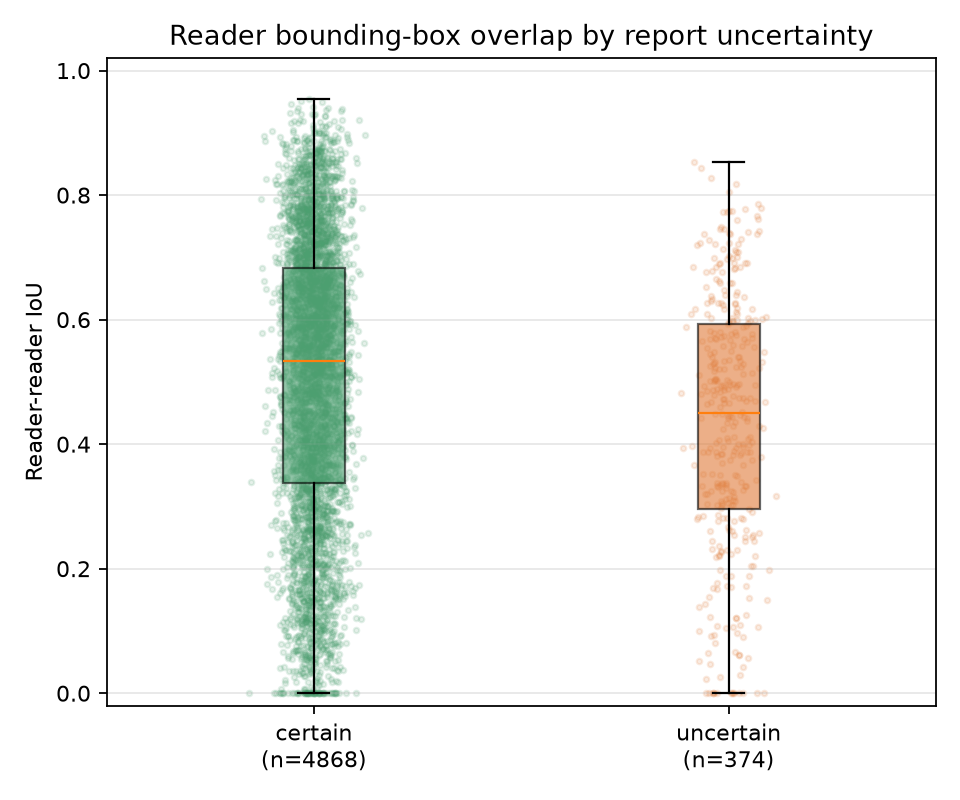

### IoU histogram by group

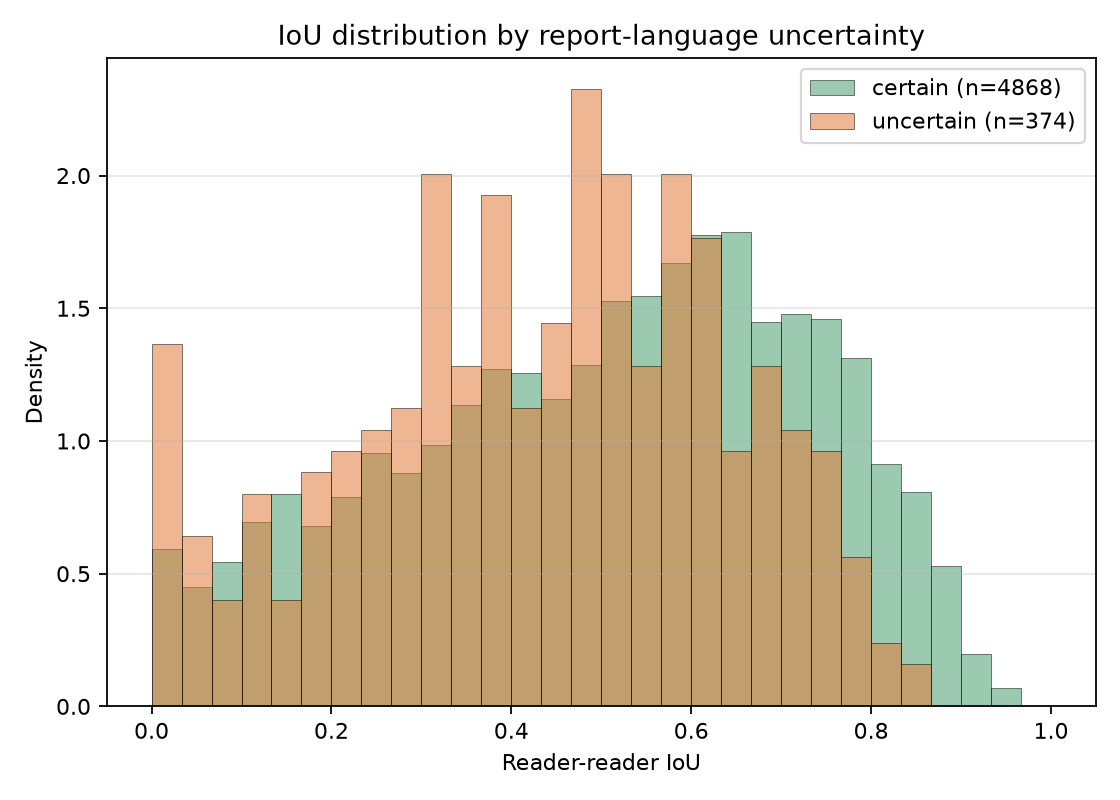

### Example grid

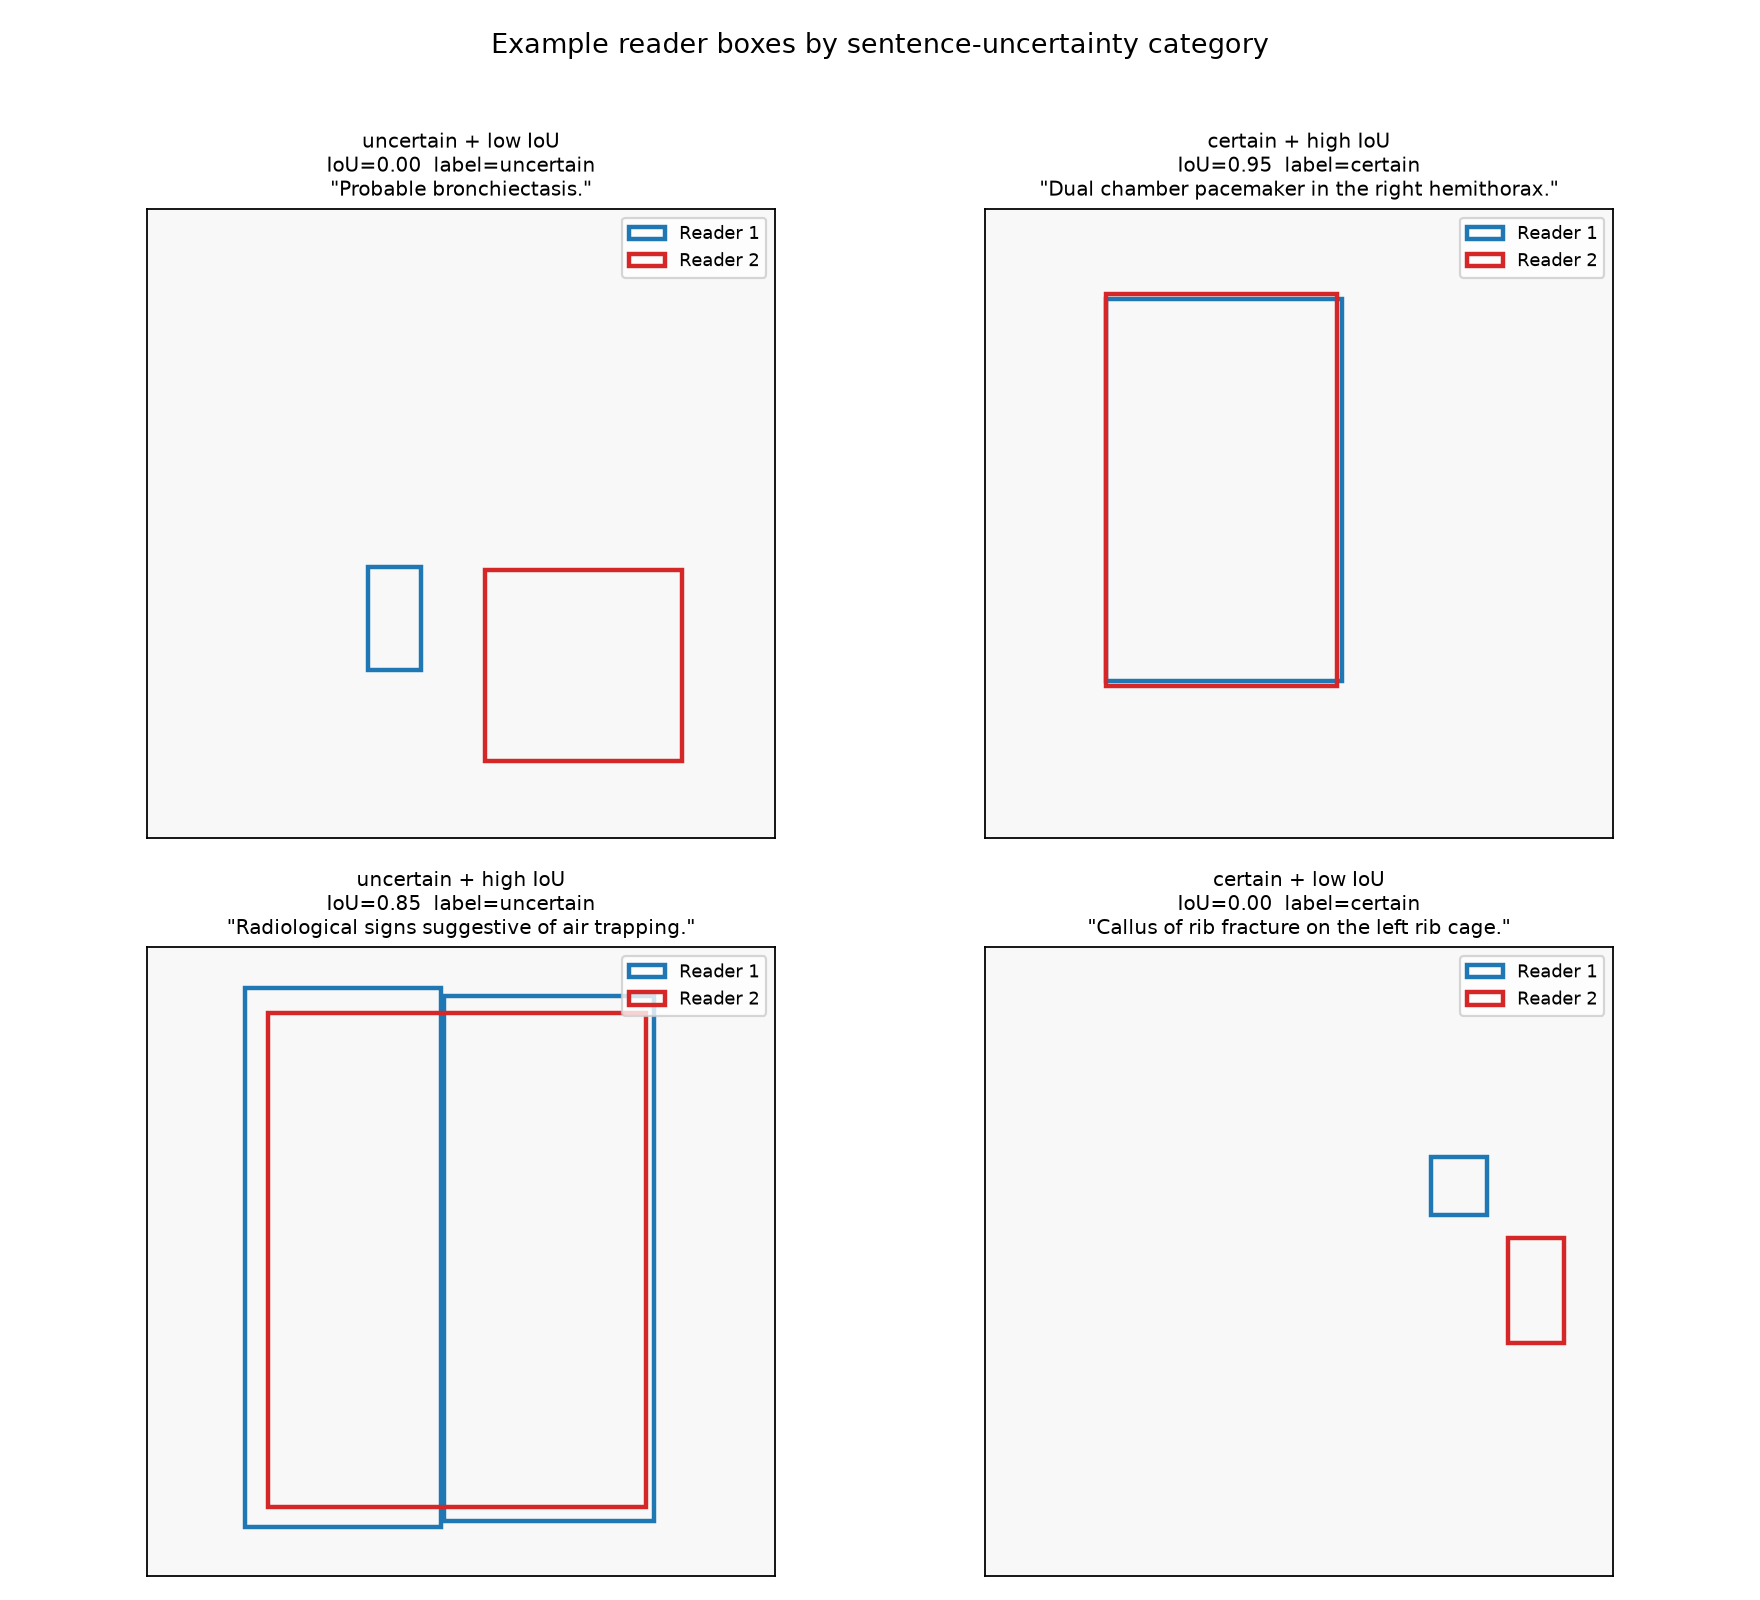

In [6]:
from IPython.display import Image, display, Markdown

display(Markdown('### Reader IoU by uncertainty group'))
display(Image(filename=str(FIG / 'iou_by_uncertainty_group.png')))

display(Markdown('### IoU histogram by group'))
display(Image(filename=str(FIG / 'iou_histogram_by_group.png')))

display(Markdown('### Example grid'))
display(Image(filename=str(FIG / 'example_grid.png')))

In [7]:
display(Markdown('### Per-finding control analysis (>=10 in each group)'))
pf = pd.read_csv(OUT / 'per_finding_analysis.csv')
display(pf)

display(Markdown('### Top examples: uncertain + low IoU'))
display(pd.read_csv(OUT / 'examples_uncertain_low_iou.csv').head(15))

display(Markdown('### Top examples: certain + high IoU'))
display(pd.read_csv(OUT / 'examples_certain_high_iou.csv').head(15))

### Per-finding control analysis (>=10 in each group)

,finding_label,n_certain,n_uncertain,mean_iou_certain,mean_iou_uncertain,delta_mean_iou
0,callus rib fracture,88,11,0.358954,0.259324,0.099630
1,increased density,70,12,0.442187,0.378219,0.063968
2,alveolar pattern,116,12,0.478408,0.445670,0.032738
3,pseudonodule,64,16,0.324086,0.292865,0.031221
4,vascular hilar enlargement,65,93,0.489085,0.490784,-0.001699
5,infiltrates,105,23,0.462117,0.488154,-0.026037
6,pleural effusion,157,17,0.418486,0.475013,-0.056526
7,atelectasis,49,12,0.421478,0.524851,-0.103373
8,calcified granuloma,66,10,0.274812,0.405970,-0.131158
9,nipple shadow,30,13,0.182341,0.350479,-0.168138


### Top examples: uncertain + low IoU

,sample_id,image_id,study_id,sentence,finding_label,uncertainty_label,medgemma_confidence,reader_iou,reader_disagreement,num_reader1_boxes,num_reader2_boxes
0,310105454051685308651030906920018004696_wikcux...,310105454051685308651030906920018004696_wikcux...,310105454051685308651030906920018004696,Probable bronchiectasis.,bronchiectasis,uncertain,1.0,0.000000,1.000000,1,1
1,144638709680910446346691789606893767625_0ce8mh...,144638709680910446346691789606893767625_0ce8mh...,144638709680910446346691789606893767625,Likely a nipple requiring further study with n...,nipple shadow,uncertain,1.0,0.000000,1.000000,1,1
2,290347640067496998939582311241617588915_nrt9rn...,290347640067496998939582311241617588915_nrt9rn...,290347640067496998939582311241617588915,Apparent enlargement of the mediastinum in rel...,mediastinal enlargement,uncertain,1.0,0.000000,1.000000,1,1
3,286512881682145841803981449499438571086_fo3gcl...,286512881682145841803981449499438571086_fo3gcl...,286512881682145841803981449499438571086,Some dense nodules suggestive of granuloma.,granuloma,uncertain,1.0,0.000000,1.000000,2,1
4,170075271251424132483287091141692711333_aqv7bb...,170075271251424132483287091141692711333_aqv7bb...,170075271251424132483287091141692711333,Rib fracture probably old.,callus rib fracture,uncertain,1.0,0.000000,1.000000,1,1
5,57689621977024693748648832766382888122_26l7wi....,57689621977024693748648832766382888122_26l7wi.png,57689621977024693748648832766382888122,Could correspond to a prominent partially calc...,calcified densities,uncertain,1.0,0.000000,1.000000,1,2
6,74583954294003090437004288481086890657_i4ole0....,74583954294003090437004288481086890657_i4ole0.png,74583954294003090437004288481086890657,A retrocardiac air image suggesting a bulla.,bullas,uncertain,1.0,0.000000,1.000000,1,1
7,213068864760875076734003687736488691356_dy86vm...,213068864760875076734003687736488691356_dy86vm...,213068864760875076734003687736488691356,Pseudonodular image projected over the right a...,pseudonodule,uncertain,1.0,0.000000,1.000000,1,1
8,197874628007485655843908495967937654268_jm3pgh...,197874628007485655843908495967937654268_jm3pgh...,197874628007485655843908495967937654268,"Nodular image in the left middle lung field, l...",nodule,uncertain,1.0,0.000000,1.000000,1,1
9,128658723533936727313039639253606529615_ubva4c...,128658723533936727313039639253606529615_ubva4c...,128658723533936727313039639253606529615,Basal nodule compatible with nipple.,pseudonodule,uncertain,1.0,0.000000,1.000000,1,1


### Top examples: certain + high IoU

,sample_id,image_id,study_id,sentence,finding_label,uncertainty_label,medgemma_confidence,reader_iou,reader_disagreement,num_reader1_boxes,num_reader2_boxes
0,225338863619902621941453767357759185597_5p2fbf...,225338863619902621941453767357759185597_5p2fbf...,225338863619902621941453767357759185597,Dual chamber pacemaker in the right hemithorax.,dual chamber device,certain,0.5,0.953737,0.046263,1,1
1,12175588729721291971222019600123665325_-wrngm....,12175588729721291971222019600123665325_-wrngm.png,12175588729721291971222019600123665325,Dorsolumbar scoliosis.,scoliosis,certain,0.5,0.950749,0.049251,1,1
2,114423946033767506884698286401202623927_0ec2ga...,114423946033767506884698286401202623927_0ec2ga...,114423946033767506884698286401202623927,Aortic elongation.,aortic elongation,certain,0.5,0.950131,0.049869,1,1
3,143017709468319501772997901482020520995_u3pt37...,143017709468319501772997901482020520995_u3pt37...,143017709468319501772997901482020520995,Cardiothoracic index at the high limit of norm...,cardiomegaly,certain,0.5,0.945946,0.054054,1,1
4,253376165283766164953294273982388832515_j40igm...,253376165283766164953294273982388832515_j40igm...,253376165283766164953294273982388832515,Pacemaker with sensor tip projected over the r...,pacemaker,certain,0.5,0.941750,0.058250,1,1
5,251723533615139334736485169349312940121_r66lu2...,251723533615139334736485169349312940121_r66lu2...,251723533615139334736485169349312940121,Dual chamber pacemaker.,dual chamber device,certain,0.5,0.939969,0.060031,1,1
6,60376990954343905639421225519811011941_lwyd87....,60376990954343905639421225519811011941_lwyd87.png,60376990954343905639421225519811011941,Aortic elongation.,aortic elongation,certain,0.5,0.939581,0.060419,1,1
7,312494184270223027521381831307451031900_9yiqcu...,312494184270223027521381831307451031900_9yiqcu...,312494184270223027521381831307451031900,Chronic changes in lung parenchyma.,chronic changes,certain,0.5,0.938420,0.061580,1,1
8,47279971947360117001092773771145024549_bnpegg....,47279971947360117001092773771145024549_bnpegg.png,47279971947360117001092773771145024549,Cardiothoracic index at the high limit of normal.,cardiomegaly,certain,0.5,0.936527,0.063473,1,1
9,238957302030837305251620604840035789903_1ec6d8...,238957302030837305251620604840035789903_1ec6d8...,238957302030837305251620604840035789903,Pacemaker.,pacemaker,certain,0.5,0.935294,0.064706,1,1


## 6. 15 random uncertain + 15 random certain example sentences

(Rule-based labels, with the hedge word(s) that triggered each `uncertain` classification.)

In [8]:
import pandas as pd, pathlib, textwrap

merged = pd.read_csv(PROC / 'samples_with_uncertainty_and_iou.csv')

K = 15
RNG_SEED = 0

def show_examples(df, label, k=K, seed=RNG_SEED):
    sub = df[df['uncertainty_label'] == label]
    if len(sub) == 0:
        print(f'No {label} samples.')
        return
    sample = sub.sample(min(k, len(sub)), random_state=seed)
    print(f'\n=== {k} {label.upper()} examples (n={len(sub)} total) ===')
    for i, (_, row) in enumerate(sample.iterrows(), 1):
        sentence = textwrap.shorten(str(row['sentence']), width=140, placeholder='...')
        triggers = row.get('uncertainty_triggers', '')
        iou = float(row.get('reader_iou', float('nan')))
        finding = row.get('finding_label', '')
        print(f'{i:>2}. [{finding}]  IoU={iou:.2f}')
        print(f'    "{sentence}"')
        if isinstance(triggers, str) and triggers and triggers not in ('[]', 'nan'):
            print(f'    triggers: {triggers}')

show_examples(merged, 'uncertain')
show_examples(merged, 'certain')


=== 15 UNCERTAIN examples (n=374 total) ===
 1. [vascular hilar enlargement]  IoU=0.64
    "Prominent hila of probable vascular origin."
    triggers: ['probable']
 2. [goiter]  IoU=0.49
    "Consistent with goiter."
    triggers: ['consistent with']
 3. [sclerotic bone lesion]  IoU=0.22
    "Sclerotic image in the left humeral head, in relation to a probable enchondroma, without significant changes compared to the previous study."
    triggers: ['probable']
 4. [pseudonodule]  IoU=0.63
    "A pseudonodular image persists in the right hilum, likely of vascular etiology."
    triggers: ['likely']
 5. [loculated pleural effusion]  IoU=0.78
    "Right basal image suggestive of loculated pleural effusion."
    triggers: ['suggestive of']
 6. [vascular hilar enlargement]  IoU=0.50
    "Prominent hila of probable vascular origin."
    triggers: ['probable']
 7. [alveolar pattern]  IoU=0.53
    "Diffuse bilateral interstitial-alveolar pattern predominantly in the right upper lung field, like

## 7. Summary of the merged sample table

In [9]:
print('rows:', len(merged))
display(merged['uncertainty_label'].value_counts())
display(merged.groupby('uncertainty_label')['reader_iou'].describe())

rows: 5242


uncertainty_label
certain      4868
uncertain     374
Name: count, dtype: int64

,count,mean,std,min,25%,50%,75%,max
uncertainty_label,,,,,,,,
certain,4868.0,0.503614,0.228055,0.0,0.338057,0.533031,0.683326,0.953737
uncertain,374.0,0.432389,0.207207,0.0,0.296428,0.450205,0.592400,0.853586


## 8. (Optional) Download all outputs as a zip

In [ ]:
import shutil
shutil.make_archive('/content/rule_uncertainty_outputs', 'zip',
                    root_dir=PROJECT_DIR,
                    base_dir='.')
print('Saved /content/rule_uncertainty_outputs.zip')
try:
    from google.colab import files
    files.download('/content/rule_uncertainty_outputs.zip')
except Exception:
    pass